### **K Means Clustering:**
K-means clustering is a method to group data into clusters where each piece of data is closest to the central point, or centroid, of its cluster.

#### Steps:
1. Start with K centroids by putting them at random place, Here k = 2 (random)
2. Compute distance of every point from centroid and cluster them accordingly
3. Adjust centroids so that they become center of gravity for given cluster
4. Again re-cluster every point basedon their distance with centroid
5. Again adjust centroids
6. Recompute clusters and repeat this till data points stop changing clusters

#### **Elbow Method:**
To find the optimal number of clusters (k) using SSE, plot the sum of squared distances from each data point to its cluster's centroid. Then, select k where the decrease in SSE starts to level off, known as the "elbow point."

K-means clustering might not perform well
if the data is on different scales. It's
recommended to preprocess the data and
scale it using the min-max method or
standard scaling method.


In real-world situations, having many features
can make it difficult to determine the value of
k. To address this, we compute SSE for each k
and plot the elbow chart to find the optimal k.

 In k-means, there's an API called inertia, which
represents the sum of squared distances
(errors).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


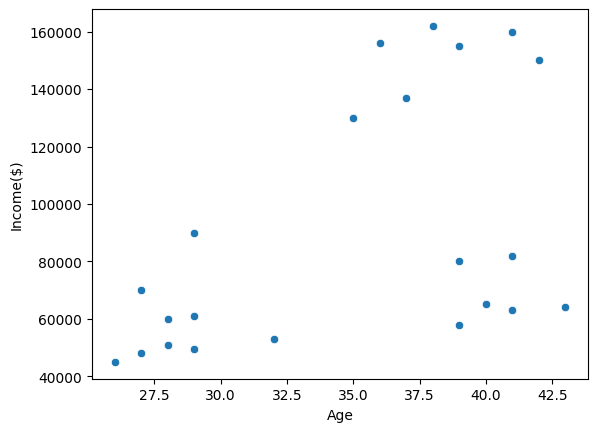

In [5]:
sns.scatterplot(data=df, x = 'Age', y = 'Income($)')
plt.show()

We have to apply clusering algorithm on this data to find the groups of people with their income level.

In [6]:
# Create cluster 
km = KMeans(n_clusters=3) # No of cluster are visible in this case which is 3 that's why
km.fit(df[['Age','Income($)']])

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


So here the cluster is created on our given data

In [8]:
km.labels_ # It gives the lables of those clusters 

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Let's add these into our Data Frame.

In [9]:
df['Cluster'] = km.labels_
df.head()

,Name,Age,Income($),Cluster
0,Rob,27,70000,0
1,Michael,29,90000,0
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


Now let's plot scatter plot with the color which indicates that which cluster that perticuler record belongs to.

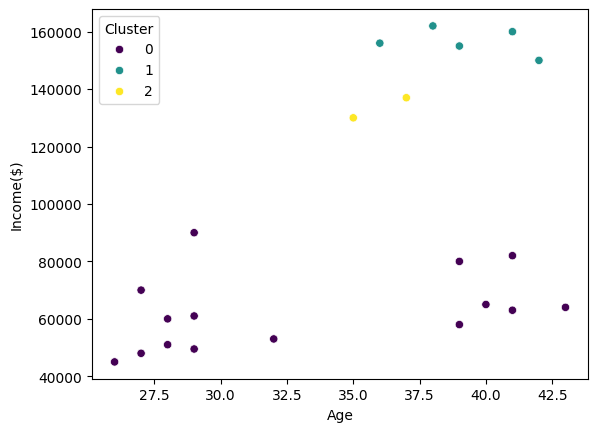

In [11]:
sns.scatterplot(data = df, x = 'Age', y = 'Income($)', palette='viridis', hue = 'Cluster' )
plt.show()

As you can see that clusters are created but they are so inaccurate because the data is not scaled.

Let's scale the data first.

In [23]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['Age','Income($)']])
df_scaled = pd.DataFrame(scaled_features, columns=['Age','Income($)'])
df_scaled.head()

,Age,Income($)
0,-1.356055,-0.480684
1,-1.009157,-0.010159
2,-1.009157,-0.692421
3,-1.182606,-0.715947
4,1.245679,1.401417


In [26]:
# Let's create clusters again now on scaled data
km_scaled = KMeans(n_clusters=3)
km_scaled.fit(df_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [27]:
# Let's check labels now
km_scaled.labels_

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2])

Let's add these into our Scaled Data Frame.

In [28]:
df_scaled['Cluster'] = km.labels_
df_scaled.head()

,Age,Income($),Cluster
0,-1.356055,-0.480684,0
1,-1.009157,-0.010159,0
2,-1.009157,-0.692421,0
3,-1.182606,-0.715947,0
4,1.245679,1.401417,2


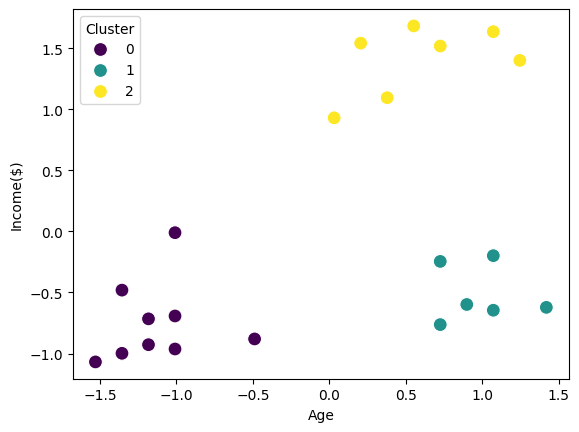

In [34]:
sns.scatterplot(data = df_scaled, x = 'Age', y = 'Income($)', palette='viridis', hue = 'Cluster', s = 100)
plt.show()

As you can see now we got correct 3 clusters for our data.

Ok so now, these clusters also has thier centers. Which are known as centroids.

In [52]:
centroids = km_scaled.cluster_centers_
centroids

array([[-1.1247901 , -0.74862223],
       [ 0.60143983,  1.40141653],
       [ 0.98550535, -0.51205261]])

Let's show these centers too in our scatterplot.

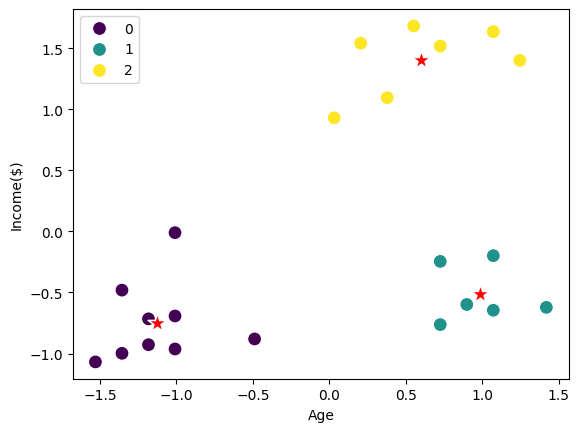

In [55]:
sns.scatterplot(data = df_scaled, x = 'Age', y = 'Income($)', palette='viridis', hue = 'Cluster', s = 100)
sns.scatterplot(x = centroids[:,0], y = centroids[:,1],  c = 'red', marker = '*' , s = 200)
plt.show()

So that's how centroids are formed internally by KMeans Algorithm.

Now here we chose k = 3 just by intuation. In reality, when we have many features, we use the Elbow Method to decide the optimal value of K.

### Elbow Method:

In [58]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df_scaled[['Age','Income($)']])
    sse.append(km.inertia_)
sse

[43.99999999999999,
 20.12283204647428,
 3.889308657130143,
 3.2897106439409898,
 2.30764705753129,
 1.8381657088216812,
 1.8921921019424854,
 1.2446607532162628,
 1.0162801670512198]

Now let's plot graph for it so we can decide our optimal k value from the Elbow graph.

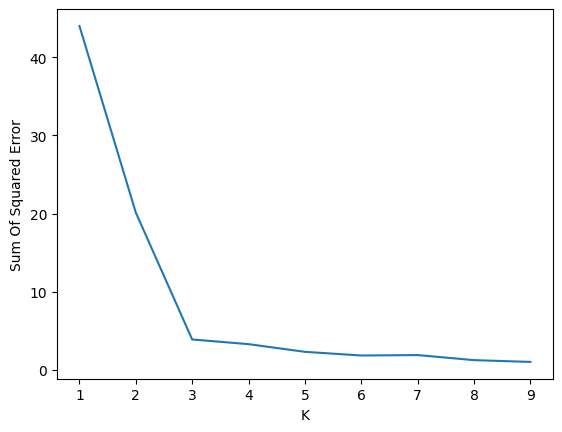

In [60]:
plt.plot(k_rng , sse)
plt.xlabel('K')
plt.ylabel('Sum Of Squared Error')
plt.show()

So it's visible that our Elbow tip is at K = 3. Which is our optimal choice for the clusters.